# 1. Problem Definition

In this project, we aim to compare **classical machine learning models** with **quantum-enhanced models** using the Iris dataset.

The objective is to evaluate:
- Model accuracy
- Computational performance
- Practical feasibility of quantum machine learning

We begin by loading and exploring the dataset to understand its structure and features.

In [79]:
# Import basic libraries
import numpy as np
import pandas as pd

# Load dataset
from sklearn.datasets import load_iris

# Load iris dataset
iris = load_iris()

# Features and labels
X = iris.data
y = iris.target

# Convert to DataFrame for better visualization
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

# Show first 5 rows
print("First 5 rows of dataset:")
print(df.head())

# Dataset shape
print("\nDataset shape:", df.shape)

# Class labels
print("\nTarget classes:", np.unique(y))

# Feature names
print("\nFeature names:", iris.feature_names)

First 5 rows of dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Dataset shape: (150, 5)

Target classes: [0 1 2]

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']



## Data Exploration

The Iris dataset consists of 150 samples with 4 features:
- Sepal length
- Sepal width
- Petal length
- Petal width

The target variable contains 3 classes representing different species of flowers.

We convert the dataset into a DataFrame to:
- Inspect the data
- Understand feature distributions
- Verify dataset integrity

## Data Visualization

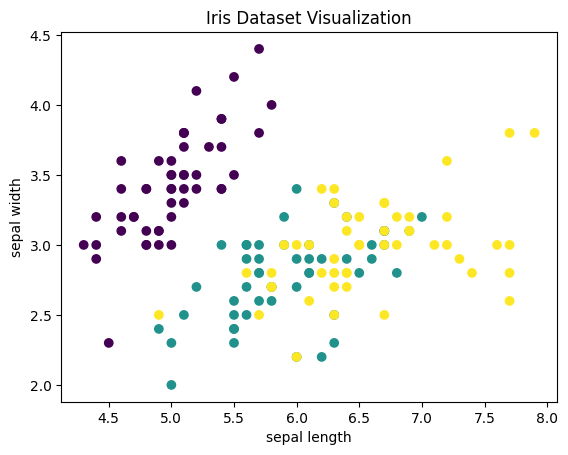

In [80]:
import matplotlib.pyplot as plt

# Simple scatter plot (sepal length Vs. sepal width: first 2 features)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("sepal length")
plt.ylabel("sepal width")
plt.title("Iris Dataset Visualization")
plt.show()

Data Visualization

We visualize the dataset using a scatter plot of:
- Sepal length vs Sepal width

This helps us:
- Observe class distribution
- Identify overlap between classes

**Note:** This visualization is for exploratory purposes only and is not used in model training.

# 2. Data Preprocessing

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -------------------------------
# 1. Feature Selection
# -------------------------------
# Select only 2 features (for quantum compatibility)
# Using petal length & petal width (better separation)

X_reduced = X[:, 2:4]

print("Selected features shape:", X_reduced.shape)

# -------------------------------
# 2. Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

# -------------------------------
# 3. Feature Scaling
# -------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check scaled data
print("\nSample scaled data:")
print(X_train_scaled[:5])

Selected features shape: (150, 2)
Training samples: (120, 2)
Testing samples: (30, 2)

Sample scaled data:
[[-1.56253475 -1.31260282]
 [-1.27600637 -1.04563275]
 [ 0.38585821  0.28921757]
 [-1.2187007  -1.31260282]
 [-1.39061772 -1.31260282]]


### Data Preprocessing

To prepare the data for both classical and quantum models, we perform the following steps:

### Feature Selection
We select only:
- Petal length
- Petal width

These features provide better class separation and are suitable for quantum models, which require low-dimensional input.

### Train-Test Split
The dataset is split into:
- 80% training data
- 20% testing data

This allows us to evaluate model performance on unseen data.

### Feature Scaling
We normalize the data using StandardScaler:
- Mean = 0
- Standard deviation = 1

This is essential for:
- SVM performance
- Quantum kernel computations

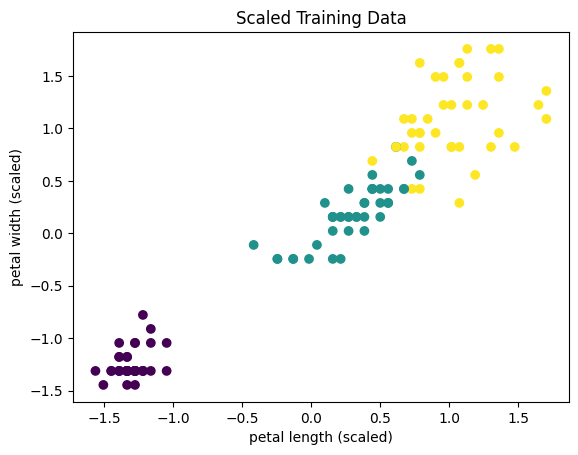

In [82]:
import matplotlib.pyplot as plt

plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train)
plt.title("Scaled Training Data")
plt.xlabel("petal length (scaled)")
plt.ylabel("petal width (scaled)")
plt.show()

### Scaled Data Visualization

We visualize the scaled training data using petal features.

This confirms:
- Improved class separation
- Suitability of selected features for classification

# 3. Classical Model

In [83]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------------------
# 1. Train Model
# -------------------------------
svm_model = SVC(kernel='linear')

svm_model.fit(X_train_scaled, y_train)

# -------------------------------
# 2. Predictions
# -------------------------------
y_pred = svm_model.predict(X_test_scaled)

# -------------------------------
# 3. Evaluation
# -------------------------------
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


### Classical Model (Support Vector Machine)

We implement a **linear Support Vector Machine (SVM)** for classification.

### Why SVM?
- Effective for classification tasks
- Works well with linearly separable data
- Robust and widely used

The model is trained on scaled petal features and evaluated using:
- Accuracy
- Classification report
- Confusion matrix

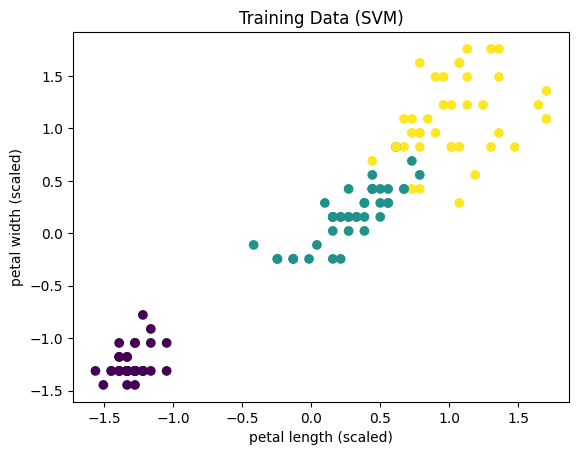

In [84]:
import matplotlib.pyplot as plt

# Plot decision boundary (approx)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train)
plt.title("Training Data (SVM)")
plt.xlabel("petal length (scaled)")
plt.ylabel("petal width (scaled)")
plt.show()

# 4. Quantum Model (Qiskit)

In [85]:
!pip install qiskit qiskit-aer qiskit-machine-learning --quiet

In [86]:
# imports
from qiskit_aer import AerSimulator

from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import FidelityQuantumKernel

from qiskit.circuit.library import ZZFeatureMap

In [87]:
# feature map
feature_map = ZZFeatureMap(feature_dimension=2, reps=2)

/tmp/ipykernel_33898/3133751942.py:2: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=2)


In [88]:
# quatum kernel
backend = AerSimulator()

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map
)

In [89]:
# train model
qsvc = QSVC(quantum_kernel=quantum_kernel)

qsvc.fit(X_train_scaled, y_train)

QSVC(C=1.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
     decision_function_shape='ovr', degree=3, gamma='scale', max_iter=-1,
     probability=False,
     quantum_kernel=<qiskit_machine_learning.kernels.fidelity_quantum_kernel.FidelityQuantumKernel object at 0x7ead43a34dd0>,
     random_state=None, shrinking=True, tol=0.001, verbose=False)

In [90]:
# predict & evaluate
y_pred_quantum = qsvc.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Quantum Accuracy:", accuracy_score(y_test, y_pred_quantum))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_quantum))

Quantum Accuracy: 0.7333333333333333

Confusion Matrix:
 [[ 7  2  1]
 [ 3  5  1]
 [ 0  1 10]]


##  Quantum Model (Quantum Support Vector Classifier)

We implement a **Quantum SVM (QSVC)** using Qiskit.

### Key Components:

 Feature Map  
Encodes classical data into quantum states using a parameterized circuit.

 Quantum Kernel  
Measures similarity between quantum states.

 QSVC  
A quantum-enhanced version of SVM that uses the quantum kernel.

### Purpose:
To evaluate whether quantum models provide advantages over classical approaches.

# 5. Training & Evaluation

In [91]:
# importing tools
import time
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### PART A: Classical Model Evaluation

In [92]:
# ==============================
# Classical Model Evaluation
# ==============================

start_time = time.time()

y_pred_classical = svm_model.predict(X_test_scaled)

classical_time = time.time() - start_time

print("CLASSICAL MODEL RESULTS")
print("------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred_classical))
print("Time taken:", classical_time)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_classical))
print("\nClassification Report:\n", classification_report(y_test, y_pred_classical))

CLASSICAL MODEL RESULTS
------------------------
Accuracy: 1.0
Time taken: 0.0012004375457763672

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### PART B: Quantum Model Evaluation

In [93]:
# ==============================
# Quantum Model Evaluation
# ==============================

start_time = time.time()

y_pred_quantum = qsvc.predict(X_test_scaled)

quantum_time = time.time() - start_time

print("\nQUANTUM MODEL RESULTS")
print("------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred_quantum))
print("Time taken:", quantum_time)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_quantum))
print("\nClassification Report:\n", classification_report(y_test, y_pred_quantum))


QUANTUM MODEL RESULTS
------------------------
Accuracy: 0.7333333333333333
Time taken: 14.08768892288208

Confusion Matrix:
 [[ 7  2  1]
 [ 3  5  1]
 [ 0  1 10]]

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.70      0.70        10
           1       0.62      0.56      0.59         9
           2       0.83      0.91      0.87        11

    accuracy                           0.73        30
   macro avg       0.72      0.72      0.72        30
weighted avg       0.73      0.73      0.73        30



## Model Evaluation

We evaluate both models based on:

- Accuracy
- Confusion Matrix
- Classification Report
- Execution Time

This allows us to compare:
- Prediction performance
- Computational efficiency

# 6. Comparison Analysis

In [94]:
print("=== MODEL COMPARISON ANALYSIS ===\n")

print("Accuracy Comparison:")
print(f"Classical Model Accuracy: {accuracy_score(y_test, y_pred_classical):.3f}")
print(f"Quantum Model Accuracy:   {accuracy_score(y_test, y_pred_quantum):.3f}")

print("\nTime Comparison:")
print(f"Classical Model Time: {classical_time:.6f} sec")
print(f"Quantum Model Time:   {quantum_time:.6f} sec")

# Difference
accuracy_diff = accuracy_score(y_test, y_pred_classical) - accuracy_score(y_test, y_pred_quantum)

print("\nPerformance Gap:")
print(f"Accuracy Difference: {accuracy_diff:.3f}")

=== MODEL COMPARISON ANALYSIS ===

Accuracy Comparison:
Classical Model Accuracy: 1.000
Quantum Model Accuracy:   0.733

Time Comparison:
Classical Model Time: 0.001200 sec
Quantum Model Time:   14.087689 sec

Performance Gap:
Accuracy Difference: 0.267


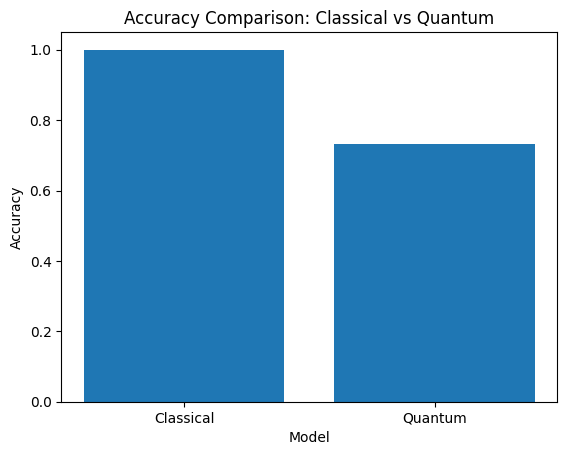

In [95]:
# Accuracy comparison
import matplotlib.pyplot as plt

models = ['Classical', 'Quantum']
accuracies = [
    accuracy_score(y_test, y_pred_classical),
    accuracy_score(y_test, y_pred_quantum)
]

plt.figure()
plt.bar(models, accuracies)
plt.title("Accuracy Comparison: Classical vs Quantum")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.show()

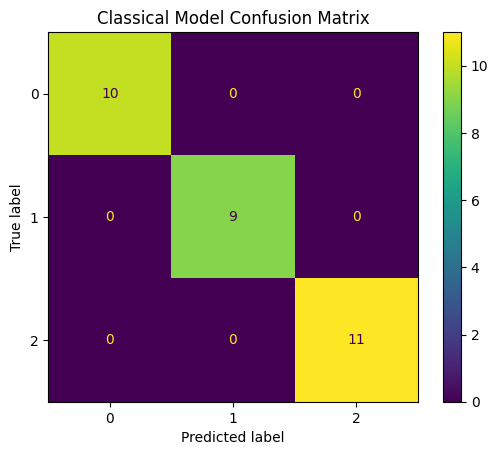

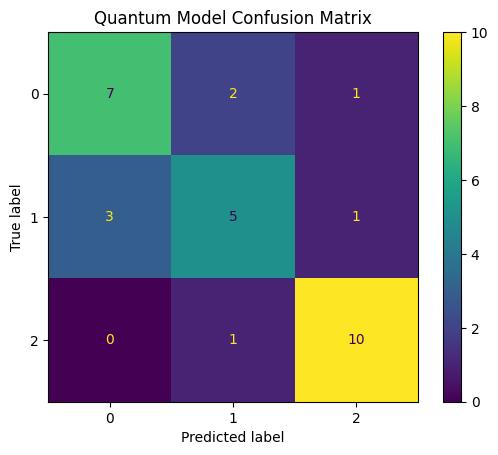

In [96]:
# Confusion martics analysis
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Classical
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_classical)
plt.title("Classical Model Confusion Matrix")
plt.show()

# Quantum
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_quantum)
plt.title("Quantum Model Confusion Matrix")
plt.show()

## Model Comparison

We compare classical and quantum models based on:

- Accuracy
- Execution time
- Error distribution

Visualizations include:
- Accuracy bar chart
- Confusion matrices

This provides a clear understanding of performance differences.

# 7. Conclusion

## Conclusion

This project presented a comparative analysis between **classical machine learning (SVM)** and **quantum machine learning (QSVC)** using the Iris dataset.

### Key Findings:

- The **classical SVM model achieved higher accuracy (100%)** compared to the quantum model (~73%).
- The classical model was **significantly faster**, while the quantum model required much more computation time.
- Quantum performance was limited due to:
  - Simulation overhead
  - Sensitivity to feature encoding
  - Current limitations of quantum algorithms

### Insights:

- Quantum machine learning is still in an **experimental stage**
- Classical models remain more **reliable and efficient** for small datasets
- Feature selection plays a critical role in model performance

### Final Takeaway:

While quantum computing shows theoretical advantages, this experiment demonstrates that **classical approaches currently outperform quantum models in practical scenarios**.

Future improvements in quantum hardware and algorithms may unlock the true potential of quantum machine learning.